# Notebook 04: Discordant Case Deep Dive

**Tempus HER2 Coding Challenge**

This notebook investigates the 35 IHC-negative / RNA-high discordant patients identified
in Notebook 02. The 03a binary HER2 classifier, trained on IHC labels, predicted nearly
all of them as negative — which tells us they are not simply mislabeled HER2-positive
patients. The question shifts: *what are these patients, and is there a coherent subgroup
that might benefit from HER2-targeted therapy?*

Three complementary approaches:
1. **Concordant-only model** — retrain on unambiguous cases, score discordant patients as outliers
2. **CN-stratified biology** — separate amplicon-driven from transcriptionally-driven ERBB2 elevation
3. **Consensus molecular HER2 score** — synthesize multi-model probabilities into a patient-level dossier

---
## 1. Setup and Data Loading

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    has_xgb = True
except ImportError:
    has_xgb = False

try:
    import shap
    has_shap = True
except ImportError:
    has_shap = False

try:
    import gseapy as gp
    has_gseapy = True
except ImportError:
    has_gseapy = False

from src.utils import (
    load_intermediate, load_gene_cols, save_intermediate, savefig,
    setup_plotting, get_color
)

setup_plotting()
print(f"XGBoost: {'available' if has_xgb else 'NOT available'}")
print(f"SHAP: {'available' if has_shap else 'NOT available'}")
print(f"gseapy: {'available' if has_gseapy else 'NOT available'}")

XGBoost: available
SHAP: available
gseapy: available


In [2]:
# Load intermediates from prior notebooks
clinical = load_intermediate('01_clinical_qc')
tumor_norm = load_intermediate('01_tumor_norm')
gene_cols = load_gene_cols()
cohort_c = load_intermediate('02_multimodal_cohort')
discordant_df = load_intermediate('02_discordant_cases')
subtype_df = load_intermediate('02_subtype_assignments')
umap_df = load_intermediate('02_umap_embeddings')
predictions_03a = load_intermediate('03_ml_predictions')
ssgsea_scores = load_intermediate('03_ssgsea_scores')

print(f"\nDiscordant cases loaded: {len(discordant_df)} records")
print(f"Discordance types: {discordant_df['discordance_type'].value_counts().to_dict()}")

  Loaded: outputs\01_clinical_qc.parquet  (1108 rows × 148 cols)
  Loaded: outputs\01_tumor_norm.parquet  (1093 rows × 17638 cols)
  Loaded: outputs\01_gene_cols.json  (17637 genes)
  Loaded: outputs\02_multimodal_cohort.parquet  (966 rows × 17786 cols)
  Loaded: outputs\02_discordant_cases.parquet  (69 rows × 8 cols)
  Loaded: outputs\02_subtype_assignments.parquet  (1093 rows × 3 cols)
  Loaded: outputs\02_umap_embeddings.parquet  (1093 rows × 3 cols)
  Loaded: outputs\03_ml_predictions.parquet  (960 rows × 7 cols)
  Loaded: outputs\03_ssgsea_scores.parquet  (960 rows × 31 cols)

Discordant cases loaded: 69 records
Discordance types: {'IHC-/RNA-high': 35, 'CN-low/RNA-high': 18, 'IHC+/RNA-low': 8, 'IHC-low/FISH+': 3, 'IHC3+/FISH-': 3, 'CN-high/RNA-low': 2}


---
## 2. Cohort Definition

We define the analysis groups: the 35 IHC-/RNA-high discordant patients (split by CN
status), concordant negatives (IHC-negative with low ERBB2), and concordant positives
(IHC-positive with high ERBB2). The concordant sets serve as unambiguous reference
populations.

In [3]:
print("=" * 70)
print("COHORT DEFINITION")
print("=" * 70)

# Extract IHC-/RNA-high discordant patients
disc_rna_high = discordant_df[discordant_df['discordance_type'] == 'IHC-/RNA-high'].copy()
disc_pids = disc_rna_high['pid'].values
print(f"\nIHC-/RNA-high discordant patients: {len(disc_pids)}")

# Build a unified analysis frame from cohort_c
tumor_expr = tumor_norm.set_index('pid')

# Build analysis frame for all labeled patients
analysis = cohort_c[['pid', 'her2_composite', 'erbb2_copy_number']].copy()
analysis = analysis[analysis['her2_composite'].isin(['Positive', 'Negative'])]
analysis['ERBB2_expr'] = analysis['pid'].map(tumor_expr['ERBB2'])
analysis['GRB7_expr'] = analysis['pid'].map(tumor_expr['GRB7'])
analysis = analysis.dropna(subset=['ERBB2_expr'])

# Compute thresholds from labeled population
pos_expr = analysis.loc[analysis['her2_composite'] == 'Positive', 'ERBB2_expr']
neg_expr = analysis.loc[analysis['her2_composite'] == 'Negative', 'ERBB2_expr']

print(f"\nExpression thresholds (from labeled population):")
print(f"  Positive median: {pos_expr.median():.2f}")
print(f"  Positive 25th pctl: {pos_expr.quantile(0.25):.2f}")
print(f"  Negative median: {neg_expr.median():.2f}")
print(f"  Negative 75th pctl: {neg_expr.quantile(0.75):.2f}")

# Define concordant groups
concordant_pos = analysis[
    (analysis['her2_composite'] == 'Positive') &
    (analysis['ERBB2_expr'] >= pos_expr.quantile(0.25)) &
    (analysis['erbb2_copy_number'] >= 1)
]
concordant_neg = analysis[
    (analysis['her2_composite'] == 'Negative') &
    (analysis['ERBB2_expr'] <= neg_expr.quantile(0.75))
]

print(f"\nConcordant Positives (IHC+ & high ERBB2 & CN>=1): {len(concordant_pos)}")
print(f"Concordant Negatives (IHC- & ERBB2 <= neg 75th pctl): {len(concordant_neg)}")

# Split discordant by CN
disc_detail = disc_rna_high.merge(
    cohort_c[['pid', 'erbb2_copy_number']], on='pid', how='left',
    suffixes=('_disc', '')
)
if 'erbb2_copy_number_disc' in disc_detail.columns and 'erbb2_copy_number' not in disc_detail.columns:
    disc_detail['erbb2_copy_number'] = disc_detail['erbb2_copy_number_disc']

disc_amplified = disc_detail[disc_detail['erbb2_copy_number'] >= 2]
disc_non_amplified = disc_detail[disc_detail['erbb2_copy_number'] < 2]

print(f"\nDiscordant split by CN:")
print(f"  Amplified (CN=2): {len(disc_amplified)} patients")
print(f"  Non-amplified (CN<=1): {len(disc_non_amplified)} patients")
print(f"\nCN distribution in discordant group:")
print(disc_detail['erbb2_copy_number'].value_counts().sort_index().to_string())

COHORT DEFINITION

IHC-/RNA-high discordant patients: 35

Expression thresholds (from labeled population):
  Positive median: 15.30
  Positive 25th pctl: 13.24
  Negative median: 12.63
  Negative 75th pctl: 13.11

Concordant Positives (IHC+ & high ERBB2 & CN>=1): 108
Concordant Negatives (IHC- & ERBB2 <= neg 75th pctl): 514

Discordant split by CN:
  Amplified (CN=2): 5 patients
  Non-amplified (CN<=1): 30 patients

CN distribution in discordant group:
erbb2_copy_number
0    15
1    15
2     5


---
## 3. Concordant-Only Model (Anomaly-Aware Scoring)

The 03a model was trained on *all* labeled patients, so discordant cases were in the
training data pulling the decision boundary. Here we retrain exclusively on concordant
samples — patients where IHC and molecular data agree — so the model learns the
unambiguous positive and negative signatures. Discordant patients are then scored
against this cleaner reference.

In [4]:
print("=" * 70)
print("CONCORDANT-ONLY MODEL")
print("=" * 70)

# Use Feature Set B from 03a: curated gene panel + CN + clinical
curated_genes = [
    'ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'TCAP',
    'EGFR', 'ERBB3', 'ERBB4', 'PIK3CA', 'AKT1', 'MAPK1', 'MAPK3',
    'MTOR', 'SRC', 'STAT3', 'GRB2', 'SHC1',
    'ESR1', 'PGR', 'FOXA1', 'GATA3',
    'KRT5', 'KRT14', 'KRT17',
    'MKI67', 'CCNB1', 'AURKA', 'TOP2A',
    'MED1',
]

# Build feature matrix for all patients in cohort_c
ml_df = cohort_c[['pid', 'her2_composite', 'erbb2_copy_number']].copy()
for gene in curated_genes:
    col = f'expr_{gene}'
    if gene in tumor_expr.columns:
        ml_df[col] = ml_df['pid'].map(tumor_expr[gene])

ml_df['er_positive'] = ml_df['pid'].map(
    dict(zip(clinical['pid'], (clinical['ER Status By IHC'] == 'Positive').astype(float)))
)
ml_df['pr_positive'] = ml_df['pid'].map(
    dict(zip(clinical['pid'], (clinical['PR status by ihc'] == 'Positive').astype(float)))
)
ml_df['er_positive'] = ml_df['er_positive'].fillna(ml_df['er_positive'].median())
ml_df['pr_positive'] = ml_df['pr_positive'].fillna(ml_df['pr_positive'].median())

fs_cols = [f'expr_{g}' for g in curated_genes if f'expr_{g}' in ml_df.columns]
fs_cols += ['erbb2_copy_number', 'er_positive', 'pr_positive']
print(f"Feature set: {len(fs_cols)} features")

# Define concordant training set
concordant_pos_pids = set(concordant_pos['pid'])
concordant_neg_pids = set(concordant_neg['pid'])
concordant_pids = concordant_pos_pids | concordant_neg_pids

ml_concordant = ml_df[ml_df['pid'].isin(concordant_pids)].copy()
ml_concordant = ml_concordant.dropna(subset=fs_cols)
ml_concordant['y'] = (ml_concordant['her2_composite'] == 'Positive').astype(int)

print(f"Concordant training set: {len(ml_concordant)} patients")
print(f"  Positive: {ml_concordant['y'].sum()}")
print(f"  Negative: {(1 - ml_concordant['y']).sum():.0f}")

CONCORDANT-ONLY MODEL
Feature set: 32 features
Concordant training set: 622 patients
  Positive: 108
  Negative: 514


In [5]:
# Stratified 5-fold CV on concordant data
X_conc = ml_concordant[fs_cols].values
y_conc = ml_concordant['y'].values
pids_conc = ml_concordant['pid'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest (same config as 03a best model)
rf_conc = RandomForestClassifier(
    n_estimators=200, max_depth=5, random_state=42,
    class_weight='balanced', n_jobs=-1
)
y_prob_cv = cross_val_predict(rf_conc, X_conc, y_conc, cv=cv, method='predict_proba')[:, 1]

auc_conc = roc_auc_score(y_conc, y_prob_cv)
auc_pr_conc = average_precision_score(y_conc, y_prob_cv)
print(f"Concordant-only model (5-fold CV):")
print(f"  AUC-ROC: {auc_conc:.3f}")
print(f"  AUC-PR:  {auc_pr_conc:.3f}")
print(f"\n03a full-data model: AUC-ROC = 0.852 (RF, Curated Panel)")
print(f"Concordant-only:     AUC-ROC = {auc_conc:.3f}")
if auc_conc > 0.852:
    print("-> Higher AUC expected: removed ambiguous cases from training.")

# Retrain on full concordant set for scoring
rf_conc.fit(X_conc, y_conc)
print("\nModel retrained on full concordant set.")

Concordant-only model (5-fold CV):
  AUC-ROC: 1.000
  AUC-PR:  1.000

03a full-data model: AUC-ROC = 0.852 (RF, Curated Panel)
Concordant-only:     AUC-ROC = 1.000
-> Higher AUC expected: removed ambiguous cases from training.

Model retrained on full concordant set.


In [6]:
print("=" * 70)
print("SCORING DISCORDANT PATIENTS")
print("=" * 70)

# Score all patients
ml_all = ml_df.dropna(subset=fs_cols).copy()
X_all = ml_all[fs_cols].values
ml_all['conc_model_prob'] = rf_conc.predict_proba(X_all)[:, 1]

# Extract discordant patient scores
disc_scores = ml_all[ml_all['pid'].isin(disc_pids)].copy()
disc_scores = disc_scores.merge(disc_detail[['pid', 'discordance_type']], on='pid', how='left')
disc_scores['GRB7_expr'] = disc_scores['pid'].map(tumor_expr['GRB7'])

# Add 03a model probabilities
disc_scores = disc_scores.merge(
    predictions_03a[['pid', 'ml_prob_her2_positive', 'prob_L1-LR', 'prob_Random Forest', 'prob_XGBoost']],
    on='pid', how='left'
)

# Add subtype
disc_scores = disc_scores.merge(subtype_df[['pid', 'provisional_subtype']], on='pid', how='left')
disc_scores = disc_scores.sort_values('conc_model_prob', ascending=False)

print(f"\nDiscordant patients scored: {len(disc_scores)}")
print(f"\nConcordant-model P(HER2+) distribution:")
print(f"  > 0.5: {(disc_scores['conc_model_prob'] > 0.5).sum()} patients")
print(f"  0.3-0.5: {((disc_scores['conc_model_prob'] >= 0.3) & (disc_scores['conc_model_prob'] <= 0.5)).sum()} patients")
print(f"  < 0.3: {(disc_scores['conc_model_prob'] < 0.3).sum()} patients")

print(f"\n03a model P(HER2+) distribution (same patients):")
print(f"  > 0.5: {(disc_scores['ml_prob_her2_positive'] > 0.5).sum()} patients")
print(f"  0.3-0.5: {((disc_scores['ml_prob_her2_positive'] >= 0.3) & (disc_scores['ml_prob_her2_positive'] <= 0.5)).sum()} patients")
print(f"  < 0.3: {(disc_scores['ml_prob_her2_positive'] < 0.3).sum()} patients")

# Summary table
print(f"\nTop discordant patients by concordant-model probability:")
display_cols = ['pid', 'erbb2_copy_number', 'expr_ERBB2', 'GRB7_expr',
                'conc_model_prob', 'ml_prob_her2_positive', 'provisional_subtype']
display_cols = [c for c in display_cols if c in disc_scores.columns]
print(disc_scores[display_cols].head(15).to_string(index=False, float_format='{:.3f}'.format))

SCORING DISCORDANT PATIENTS

Discordant patients scored: 35

Concordant-model P(HER2+) distribution:
  > 0.5: 23 patients
  0.3-0.5: 12 patients
  < 0.3: 0 patients

03a model P(HER2+) distribution (same patients):
  > 0.5: 2 patients
  0.3-0.5: 7 patients
  < 0.3: 26 patients

Top discordant patients by concordant-model probability:
         pid  erbb2_copy_number  expr_ERBB2  GRB7_expr  conc_model_prob  ml_prob_her2_positive provisional_subtype
TCGA-A8-A08J                  2      16.848     13.161            0.978                  0.761       HER2-enriched
TCGA-D8-A1XL                  1      13.912     10.418            0.939                  0.417       HER2-enriched
TCGA-AO-A0JL                  2      14.076     11.029            0.938                  0.489          Basal-like
TCGA-BH-A0HW                  1      14.075     10.096            0.921                  0.340           Luminal A
TCGA-AN-A049                  2      13.908     10.216            0.903                  

  Saved figure: fig20_concordant_model_discordant


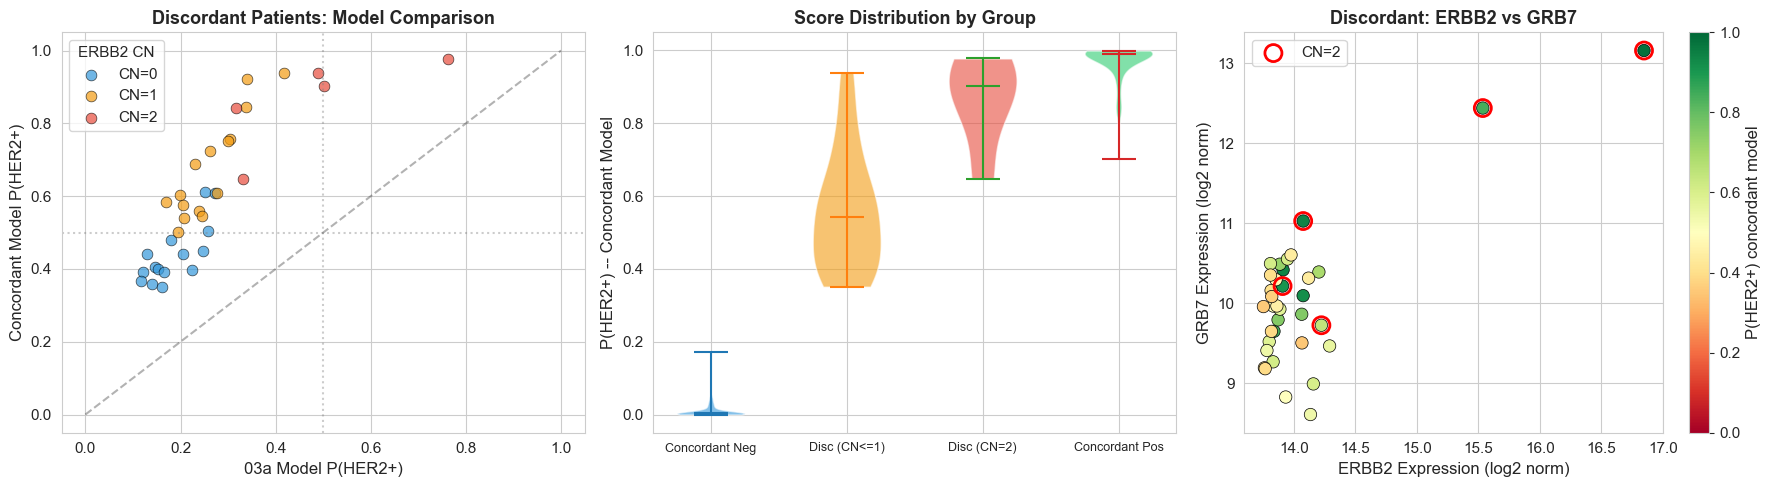

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Concordant model prob vs 03a model prob
ax = axes[0]
cn_colors = {0: '#3498db', 1: '#f39c12', 2: '#e74c3c'}
for cn_val in sorted(disc_scores['erbb2_copy_number'].dropna().unique()):
    mask = disc_scores['erbb2_copy_number'] == cn_val
    ax.scatter(disc_scores.loc[mask, 'ml_prob_her2_positive'],
               disc_scores.loc[mask, 'conc_model_prob'],
               c=cn_colors.get(int(cn_val), 'gray'), s=60, alpha=0.7,
               label=f'CN={int(cn_val)}', edgecolors='black', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.4)
ax.set_xlabel('03a Model P(HER2+)')
ax.set_ylabel('Concordant Model P(HER2+)')
ax.set_title('Discordant Patients: Model Comparison', fontweight='bold')
ax.legend(title='ERBB2 CN')

# Panel B: Distribution across groups
ax = axes[1]
groups = {
    'Concordant Neg': ml_all[ml_all['pid'].isin(concordant_neg_pids)]['conc_model_prob'],
    'Disc (CN<=1)': disc_scores[disc_scores['erbb2_copy_number'] < 2]['conc_model_prob'],
    'Disc (CN=2)': disc_scores[disc_scores['erbb2_copy_number'] >= 2]['conc_model_prob'],
    'Concordant Pos': ml_all[ml_all['pid'].isin(concordant_pos_pids)]['conc_model_prob'],
}
positions = range(len(groups))
colors_box = ['#3498db', '#f39c12', '#e74c3c', '#2ecc71']
for i, (label, vals) in enumerate(groups.items()):
    if len(vals) > 0:
        parts = ax.violinplot([vals.values], positions=[i], showmedians=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(colors_box[i])
            pc.set_alpha(0.6)
ax.set_xticks(list(positions))
ax.set_xticklabels(groups.keys(), fontsize=9)
ax.set_ylabel('P(HER2+) -- Concordant Model')
ax.set_title('Score Distribution by Group', fontweight='bold')

# Panel C: ERBB2 vs GRB7 colored by concordant prob
ax = axes[2]
sc = ax.scatter(disc_scores['expr_ERBB2'], disc_scores['GRB7_expr'],
                c=disc_scores['conc_model_prob'], cmap='RdYlGn', s=80,
                edgecolors='black', linewidth=0.5, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='P(HER2+) concordant model')
cn2_mask = disc_scores['erbb2_copy_number'] >= 2
if cn2_mask.sum() > 0:
    ax.scatter(disc_scores.loc[cn2_mask, 'expr_ERBB2'],
               disc_scores.loc[cn2_mask, 'GRB7_expr'],
               facecolors='none', edgecolors='red', s=150, linewidth=2, label='CN=2')
    ax.legend()
ax.set_xlabel('ERBB2 Expression (log2 norm)')
ax.set_ylabel('GRB7 Expression (log2 norm)')
ax.set_title('Discordant: ERBB2 vs GRB7', fontweight='bold')

plt.tight_layout()
savefig(fig, 'fig20_concordant_model_discordant')
plt.show()

### 3.1 Per-Patient SHAP Analysis

For discordant patients with concordant-model probability > 0.3, we examine which
features drive the model's prediction. This reveals whether the signal comes from ERBB2
alone or from a broader multi-gene signature.

Computing per-patient SHAP values...
  Saved figure: fig21_shap_waterfall_discordant


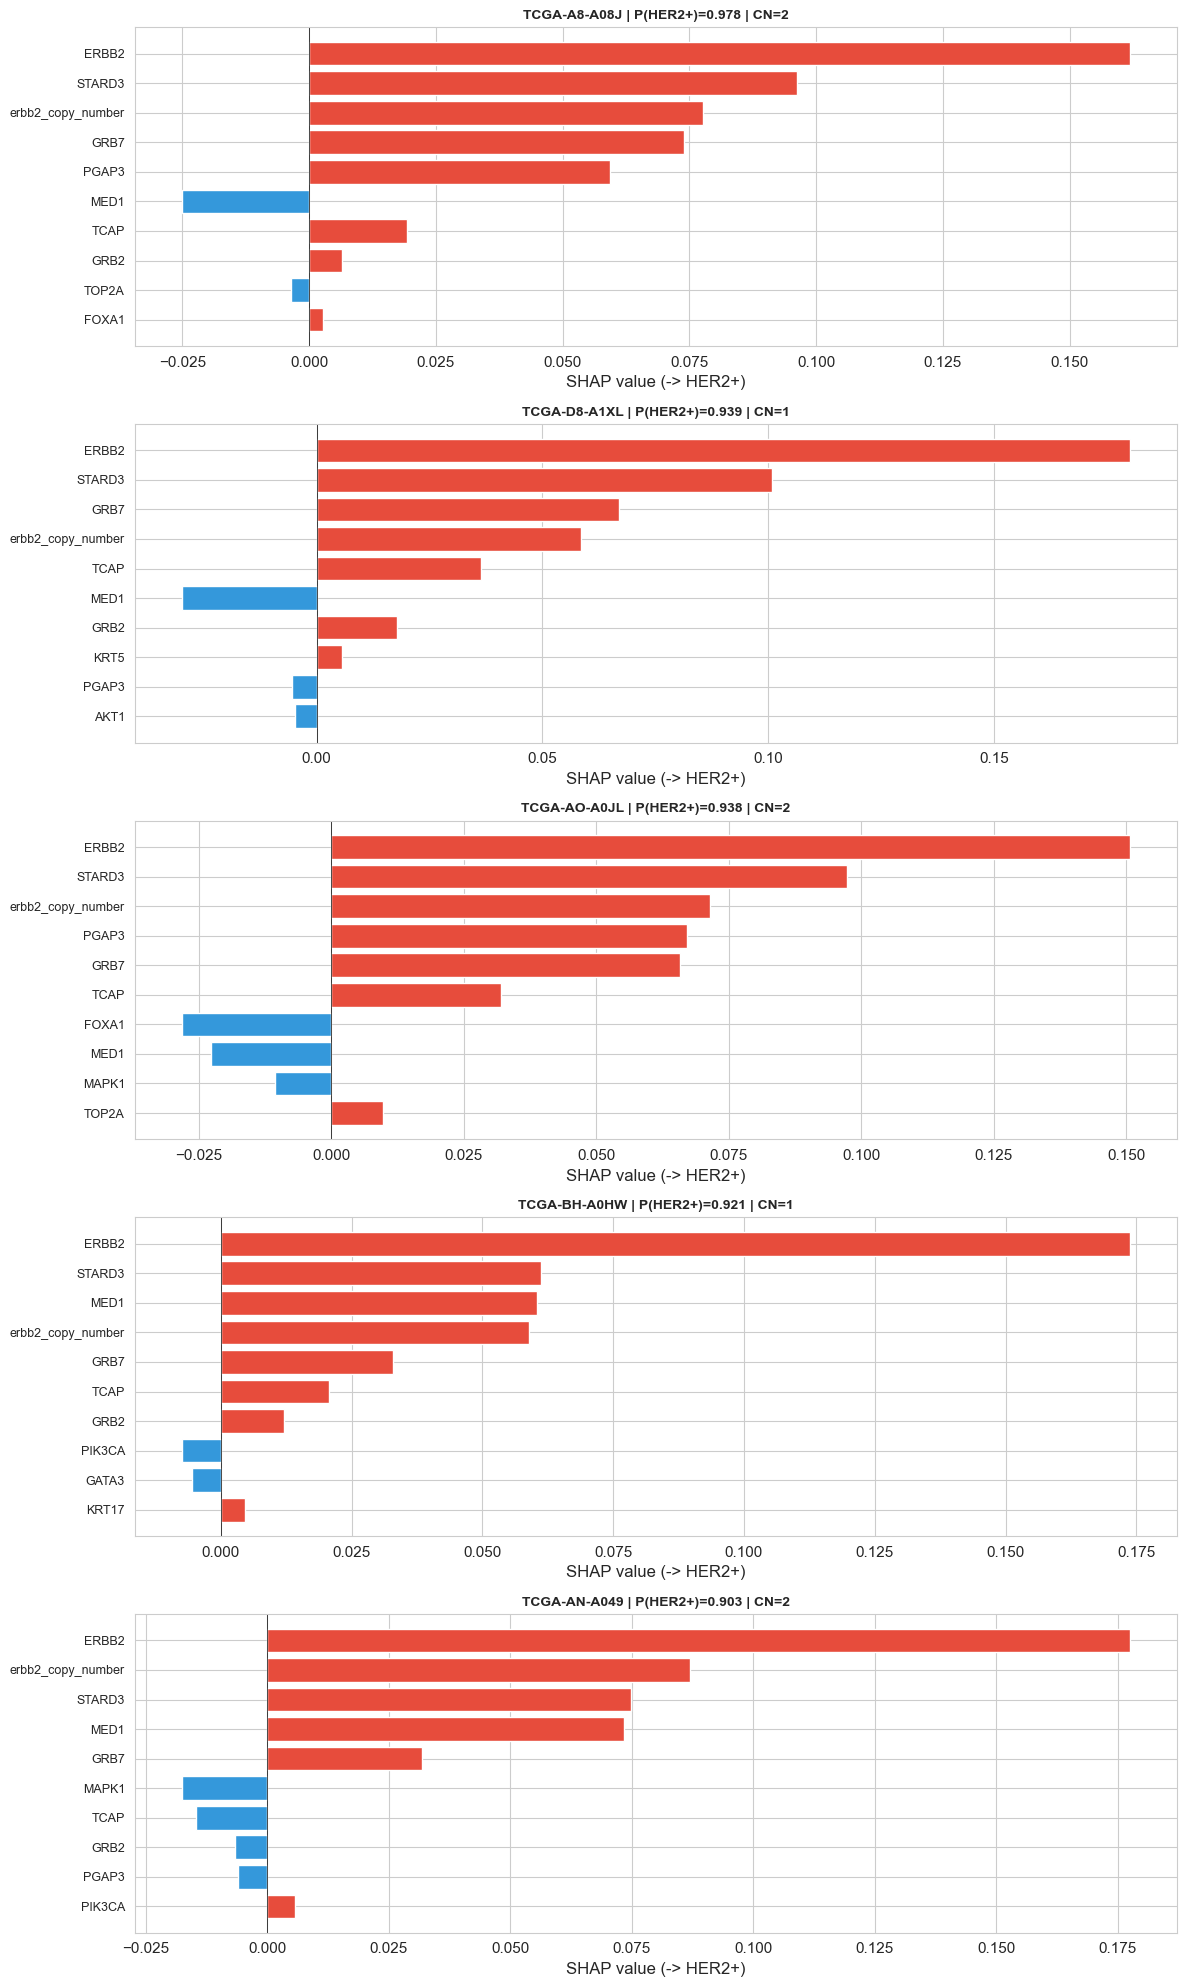

In [8]:
if has_shap:
    print("Computing per-patient SHAP values...")
    explainer = shap.TreeExplainer(rf_conc)
    X_disc = disc_scores[fs_cols].values
    shap_disc = explainer.shap_values(X_disc)

    if isinstance(shap_disc, list):
        shap_disc = shap_disc[1]
    elif isinstance(shap_disc, np.ndarray) and len(shap_disc.shape) == 3:
        shap_disc = shap_disc[:, :, 1]

    feature_names = [c.replace('expr_', '') for c in fs_cols]

    # Select patients with prob > 0.3 or CN=2
    high_prob_mask = disc_scores['conc_model_prob'].values > 0.3
    cn2_indices = np.where(disc_scores['erbb2_copy_number'].values >= 2)[0]
    high_prob_indices = np.where(high_prob_mask)[0]
    show_indices = sorted(set(list(high_prob_indices[:5]) + list(cn2_indices[:3])))

    n_show = min(len(show_indices), 6)
    if n_show > 0:
        fig, axes = plt.subplots(n_show, 1, figsize=(12, 4 * n_show))
        if n_show == 1:
            axes = [axes]

        for plot_idx, sample_idx in enumerate(show_indices[:n_show]):
            ax = axes[plot_idx]
            sv = shap_disc[sample_idx]
            pid = disc_scores.iloc[sample_idx]['pid']
            prob = disc_scores.iloc[sample_idx]['conc_model_prob']
            cn = disc_scores.iloc[sample_idx]['erbb2_copy_number']

            top_k = 10
            sorted_idx = np.argsort(np.abs(sv))[::-1][:top_k]
            sorted_sv = sv[sorted_idx]
            sorted_names = [feature_names[i] for i in sorted_idx]

            colors = ['#e74c3c' if v > 0 else '#3498db' for v in sorted_sv]
            ax.barh(range(top_k), sorted_sv[::-1], color=colors[::-1])
            ax.set_yticks(range(top_k))
            ax.set_yticklabels(sorted_names[::-1], fontsize=9)
            ax.set_xlabel('SHAP value (-> HER2+)')
            ax.set_title(f'{pid} | P(HER2+)={prob:.3f} | CN={int(cn)}',
                        fontweight='bold', fontsize=10)
            ax.axvline(0, color='black', linewidth=0.5)

        plt.tight_layout()
        savefig(fig, 'fig21_shap_waterfall_discordant')
        plt.show()
    else:
        print("No discordant patients with prob > 0.3 for SHAP analysis.")
else:
    print("SHAP not available. Skipping per-patient analysis.")

---
## 4. CN-Stratified Biology: Amplicon vs. Non-Amplicon

The discordant group is heterogeneous by mechanism. Patients with CN=2 likely have
genuine 17q12 amplification that IHC failed to detect. Patients with CN<=1 have
ERBB2 transcriptional upregulation without genomic amplification.

### 4.1 Amplified Subgroup (CN=2): Case Series

In [9]:
print("=" * 70)
print("DISCORDANT-AMPLIFIED SUBGROUP (CN=2)")
print("=" * 70)

disc_amp_pids = disc_amplified['pid'].values
print(f"Patients: {len(disc_amp_pids)}")

if len(disc_amp_pids) > 0:
    confirmed_pos_cn2 = analysis[
        (analysis['her2_composite'] == 'Positive') &
        (analysis['erbb2_copy_number'] >= 2)
    ]
    print(f"Reference: IHC+/CN=2 patients: {len(confirmed_pos_cn2)}")

    amplicon_genes = ['ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'TCAP']
    amplicon_genes_available = [g for g in amplicon_genes if g in tumor_expr.columns]

    print(f"\n17q12 Amplicon Gene Expression Comparison (median):")
    print(f"{'Gene':<12s}  {'Disc CN=2':>12s}  {'IHC+/CN=2':>12s}  {'Cohort':>12s}")
    print("-" * 52)
    for gene in amplicon_genes_available:
        disc_vals = tumor_expr.loc[tumor_expr.index.isin(disc_amp_pids), gene].dropna()
        pos_vals = tumor_expr.loc[tumor_expr.index.isin(confirmed_pos_cn2['pid']), gene].dropna()
        all_vals = tumor_expr[gene].dropna()
        d_med = disc_vals.median() if len(disc_vals) > 0 else np.nan
        p_med = pos_vals.median() if len(pos_vals) > 0 else np.nan
        a_med = all_vals.median()
        print(f"{gene:<12s}  {d_med:>12.2f}  {p_med:>12.2f}  {a_med:>12.2f}")

    print(f"\nPer-patient detail:")
    for pid in disc_amp_pids:
        row = disc_scores[disc_scores['pid'] == pid]
        if len(row) > 0:
            r = row.iloc[0]
            print(f"  {pid}: ERBB2={r.get('expr_ERBB2', np.nan):.2f}, GRB7={r.get('GRB7_expr', np.nan):.2f}, "
                  f"P(conc)={r.get('conc_model_prob', np.nan):.3f}, P(03a)={r.get('ml_prob_her2_positive', np.nan):.3f}, "
                  f"subtype={r.get('provisional_subtype', 'NA')}")

    # ssGSEA pathway comparison
    if len(ssgsea_scores) > 0:
        pathway_cols = [c for c in ssgsea_scores.columns if c.startswith('pathway_')]
        ssgsea_indexed = ssgsea_scores.set_index('pid')
        key_pathways = ['pathway_ERBB2_HER2_SIGNALING', 'pathway_PI3K_AKT_MTOR_SIGNALING',
                        'pathway_MTORC1_SIGNALING', 'pathway_ESTROGEN_RESPONSE_EARLY']
        key_pathways = [p for p in key_pathways if p in pathway_cols]
        if key_pathways:
            print(f"\nKey Pathway Scores (ssGSEA NES, median):")
            print(f"{'Pathway':<35s}  {'Disc CN=2':>10s}  {'IHC+/CN=2':>10s}  {'IHC-':>10s}")
            print("-" * 70)
            neg_pids = analysis[analysis['her2_composite'] == 'Negative']['pid']
            for pw in key_pathways:
                pw_name = pw.replace('pathway_', '').replace('_', ' ')
                d_val = ssgsea_indexed.loc[ssgsea_indexed.index.isin(disc_amp_pids), pw].median()
                p_val = ssgsea_indexed.loc[ssgsea_indexed.index.isin(confirmed_pos_cn2['pid']), pw].median()
                n_val = ssgsea_indexed.loc[ssgsea_indexed.index.isin(neg_pids), pw].median()
                print(f"{pw_name:<35s}  {d_val:>10.3f}  {p_val:>10.3f}  {n_val:>10.3f}")
else:
    print("No CN=2 patients in discordant group.")

DISCORDANT-AMPLIFIED SUBGROUP (CN=2)
Patients: 5
Reference: IHC+/CN=2 patients: 91

17q12 Amplicon Gene Expression Comparison (median):
Gene             Disc CN=2     IHC+/CN=2        Cohort
----------------------------------------------------
ERBB2                14.22         16.54         12.78
GRB7                 11.03         12.27          9.06
STARD3               11.46         12.64          9.75
PGAP3                11.69         12.86          9.86
TCAP                  4.14          4.88          2.32

Per-patient detail:
  TCGA-A2-A0YJ: ERBB2=15.54, GRB7=12.44, P(conc)=0.842, P(03a)=0.317, subtype=Basal-like
  TCGA-A8-A08J: ERBB2=16.85, GRB7=13.16, P(conc)=0.978, P(03a)=0.761, subtype=HER2-enriched
  TCGA-AN-A049: ERBB2=13.91, GRB7=10.22, P(conc)=0.903, P(03a)=0.502, subtype=HER2-enriched
  TCGA-AO-A0JL: ERBB2=14.08, GRB7=11.03, P(conc)=0.938, P(03a)=0.489, subtype=Basal-like
  TCGA-D8-A27G: ERBB2=14.22, GRB7=9.73, P(conc)=0.647, P(03a)=0.332, subtype=HER2-enriched

Key Pa

### 4.2 Non-Amplified Subgroup (CN<=1): Differential Expression

This is the larger and more biologically interesting subgroup. ERBB2 is transcriptionally
upregulated without genomic amplification. We ask: is this an isolated ERBB2 outlier, or
is there a broader co-regulated transcriptomic program?

In [10]:
print("=" * 70)
print("DIFFERENTIAL EXPRESSION: Non-Amplified Discordant vs Concordant Negative")
print("=" * 70)

disc_noamp_pids = disc_non_amplified['pid'].values
print(f"Discordant non-amplified: {len(disc_noamp_pids)}")

# Match concordant negatives on CN range (CN <= 1)
conc_neg_low_cn = analysis[
    (analysis['her2_composite'] == 'Negative') &
    (analysis['ERBB2_expr'] <= neg_expr.quantile(0.75)) &
    (analysis['erbb2_copy_number'] <= 1)
]
conc_neg_match_pids = conc_neg_low_cn['pid'].values
print(f"Matched concordant negatives (CN<=1): {len(conc_neg_match_pids)}")

# Compute DE for all genes
de_results = []
for gene in gene_cols:
    disc_vals = tumor_expr.loc[tumor_expr.index.isin(disc_noamp_pids), gene].dropna()
    conc_vals = tumor_expr.loc[tumor_expr.index.isin(conc_neg_match_pids), gene].dropna()
    if len(disc_vals) >= 3 and len(conc_vals) >= 3:
        t_stat, p_val = stats.ttest_ind(disc_vals, conc_vals, equal_var=False)
        log2fc = disc_vals.mean() - conc_vals.mean()
        de_results.append({
            'gene': gene, 't_stat': t_stat, 'p_value': p_val,
            'log2fc': log2fc, 'mean_disc': disc_vals.mean(),
            'mean_conc_neg': conc_vals.mean(),
        })

de_df = pd.DataFrame(de_results)
de_df['p_adj'] = np.minimum(de_df['p_value'] * len(de_df), 1.0)  # Bonferroni
de_df = de_df.sort_values('p_value')

n_sig_nom = (de_df['p_value'] < 0.05).sum()
n_sig_adj = (de_df['p_adj'] < 0.05).sum()
print(f"\nGenes tested: {len(de_df)}")
print(f"Nominally significant (p < 0.05): {n_sig_nom}")
print(f"Bonferroni-significant (adj p < 0.05): {n_sig_adj}")

print(f"\nTop 20 upregulated in discordant (non-amplified) vs concordant negative:")
up = de_df[de_df['log2fc'] > 0].head(20)
for _, row in up.iterrows():
    sig = '*' if row['p_adj'] < 0.05 else ''
    print(f"  {row['gene']:<15s}  log2FC={row['log2fc']:+.3f}  p={row['p_value']:.2e}  {sig}")

print(f"\nTop 20 downregulated:")
down = de_df[de_df['log2fc'] < 0].head(20)
for _, row in down.iterrows():
    sig = '*' if row['p_adj'] < 0.05 else ''
    print(f"  {row['gene']:<15s}  log2FC={row['log2fc']:+.3f}  p={row['p_value']:.2e}  {sig}")

# ERBB2 rank
erbb2_row = de_df[de_df['gene'] == 'ERBB2']
if len(erbb2_row) > 0:
    rank_by_t = (de_df['t_stat'].abs() >= erbb2_row.iloc[0]['t_stat']).sum()
    print(f"\nERBB2 rank by |t-statistic|: {rank_by_t}/{len(de_df)}")
    print(f"  log2FC = {erbb2_row.iloc[0]['log2fc']:+.3f}, t = {erbb2_row.iloc[0]['t_stat']:.2f}")

# 17q12 amplicon genes
print(f"\n17q12 amplicon genes in DE results:")
for gene in ['ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'TCAP']:
    row = de_df[de_df['gene'] == gene]
    if len(row) > 0:
        r = row.iloc[0]
        print(f"  {gene:<10s}  log2FC={r['log2fc']:+.3f}  p={r['p_value']:.2e}  t={r['t_stat']:.2f}")

DIFFERENTIAL EXPRESSION: Non-Amplified Discordant vs Concordant Negative
Discordant non-amplified: 30
Matched concordant negatives (CN<=1): 512

Genes tested: 17637
Nominally significant (p < 0.05): 5888
Bonferroni-significant (adj p < 0.05): 271

Top 20 upregulated in discordant (non-amplified) vs concordant negative:
  ERBB2            log2FC=+1.752  p=1.14e-89  *
  FOXA1            log2FC=+1.821  p=1.37e-24  *
  SPDEF            log2FC=+1.980  p=7.80e-24  *
  PGAP3            log2FC=+0.946  p=1.41e-14  *
  STARD3           log2FC=+0.702  p=4.43e-14  *
  GRB7             log2FC=+1.209  p=9.34e-14  *
  MLPH             log2FC=+1.769  p=2.40e-13  *
  C17orf28         log2FC=+1.009  p=2.61e-12  *
  PRR15            log2FC=+1.722  p=5.30e-12  *
  XBP1             log2FC=+1.259  p=7.66e-12  *
  SYT17            log2FC=+1.619  p=9.45e-12  *
  KRT19            log2FC=+1.421  p=2.26e-11  *
  ARHGAP8          log2FC=+0.799  p=9.08e-11  *
  USP40            log2FC=+0.505  p=9.89e-11  *
  SUOX 

  Saved figure: fig22_de_volcano_key_genes


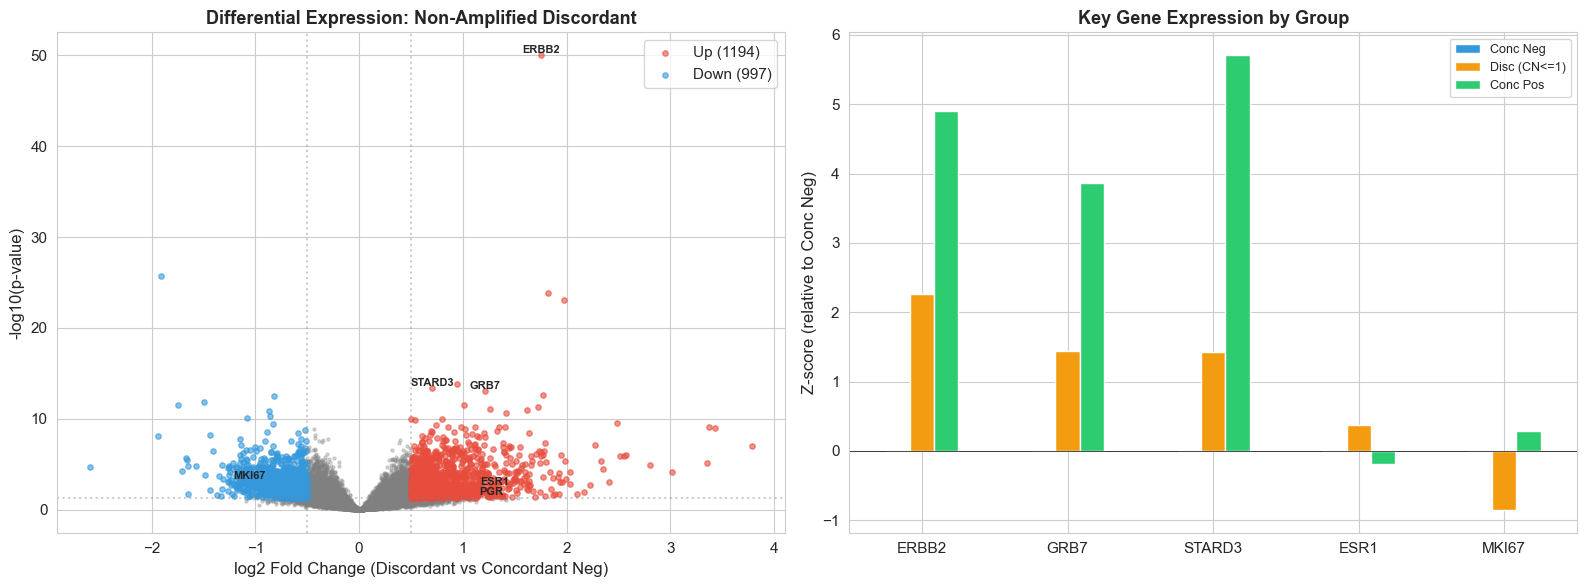

In [11]:
# Volcano plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
de_df['neg_log10p'] = -np.log10(de_df['p_value'].clip(lower=1e-50))
sig_up = (de_df['log2fc'] > 0.5) & (de_df['p_value'] < 0.05)
sig_down = (de_df['log2fc'] < -0.5) & (de_df['p_value'] < 0.05)
ns = ~sig_up & ~sig_down

ax.scatter(de_df.loc[ns, 'log2fc'], de_df.loc[ns, 'neg_log10p'], c='gray', s=5, alpha=0.3)
ax.scatter(de_df.loc[sig_up, 'log2fc'], de_df.loc[sig_up, 'neg_log10p'],
           c='#e74c3c', s=15, alpha=0.6, label=f'Up ({sig_up.sum()})')
ax.scatter(de_df.loc[sig_down, 'log2fc'], de_df.loc[sig_down, 'neg_log10p'],
           c='#3498db', s=15, alpha=0.6, label=f'Down ({sig_down.sum()})')

for gene in ['ERBB2', 'GRB7', 'STARD3', 'ESR1', 'PGR', 'MKI67']:
    row = de_df[de_df['gene'] == gene]
    if len(row) > 0:
        r = row.iloc[0]
        ax.annotate(gene, (r['log2fc'], r['neg_log10p']),
                   fontsize=8, fontweight='bold', ha='center', va='bottom')

ax.set_xlabel('log2 Fold Change (Discordant vs Concordant Neg)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Differential Expression: Non-Amplified Discordant', fontweight='bold')
ax.legend()
ax.axhline(-np.log10(0.05), color='gray', linestyle=':', alpha=0.4)
ax.axvline(-0.5, color='gray', linestyle=':', alpha=0.4)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.4)

# Panel B: Key gene expression across groups
ax = axes[1]
key_genes = ['ERBB2', 'GRB7', 'STARD3', 'ESR1', 'MKI67']
key_genes = [g for g in key_genes if g in tumor_expr.columns]

group_data = {}
for gene in key_genes:
    disc_vals = tumor_expr.loc[tumor_expr.index.isin(disc_noamp_pids), gene].dropna()
    conc_neg_vals = tumor_expr.loc[tumor_expr.index.isin(conc_neg_match_pids), gene].dropna()
    conc_pos_vals = tumor_expr.loc[tumor_expr.index.isin(concordant_pos['pid']), gene].dropna()
    mu, sigma = conc_neg_vals.mean(), max(conc_neg_vals.std(), 1e-6)
    group_data[gene] = {
        'Conc Neg': (conc_neg_vals.mean() - mu) / sigma,
        'Disc (CN<=1)': (disc_vals.mean() - mu) / sigma,
        'Conc Pos': (conc_pos_vals.mean() - mu) / sigma,
    }

gd_df = pd.DataFrame(group_data).T
gd_df.plot(kind='bar', ax=ax, color=['#3498db', '#f39c12', '#2ecc71'])
ax.set_ylabel('Z-score (relative to Conc Neg)')
ax.set_title('Key Gene Expression by Group', fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=0)

plt.tight_layout()
savefig(fig, 'fig22_de_volcano_key_genes')
plt.show()

### 4.3 Pathway Analysis on the DE Signature

We run GSEA (preranked by t-statistic) on the non-amplified discordant DE signature.
If HER2 signaling pathways are enriched despite the absence of amplification, this
supports a coherent transcriptional HER2 program.

In [12]:
if has_gseapy and len(de_df) > 100:
    print("Running GSEA on discordant non-amplified DE signature...")

    rnk = de_df.set_index('gene')['t_stat'].dropna()
    rnk = rnk[~np.isinf(rnk)]
    rnk = rnk.sort_values(ascending=False)

    CURATED_GENE_SETS = {
        'ERBB2_HER2_SIGNALING': [
            'ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'MIEN1', 'TCAP',
            'EGFR', 'ERBB3', 'ERBB4', 'GRB2', 'SOS1', 'SHC1', 'GAB1',
            'PIK3CA', 'PIK3R1', 'AKT1', 'MTOR', 'HRAS', 'KRAS', 'NRAS',
            'RAF1', 'MAP2K1', 'MAPK1', 'MAPK3', 'STAT3', 'JAK1', 'JAK2',
            'SRC', 'PLCG1', 'PTK2', 'MKI67', 'CCNB1', 'CDK1',
        ],
        'PI3K_AKT_MTOR': [
            'AKT1', 'AKT2', 'AKT3', 'PIK3CA', 'PIK3CB', 'PIK3CD',
            'PIK3R1', 'PIK3R2', 'MTOR', 'RPTOR', 'RICTOR', 'RPS6KB1',
            'EIF4EBP1', 'PTEN', 'TSC1', 'TSC2', 'RHEB', 'PDPK1',
        ],
        'ESTROGEN_RESPONSE': [
            'ESR1', 'GATA3', 'FOXA1', 'XBP1', 'TFF1', 'TFF3', 'CCND1',
            'MYB', 'PGR', 'PDZK1', 'CA12', 'STC2', 'IGFBP4', 'RARA',
            'NRIP1', 'AGR2', 'SLC39A6', 'NAT1', 'SCUBE2', 'MLPH',
        ],
        'E2F_TARGETS_PROLIFERATION': [
            'E2F1', 'E2F2', 'CCNA2', 'CCNB1', 'CCNE1', 'CDK1', 'CDK2',
            'CDC6', 'CDC20', 'MCM2', 'MCM3', 'MCM4', 'MCM5', 'MCM6',
            'PCNA', 'TOP2A', 'MKI67', 'AURKA', 'AURKB', 'PLK1', 'BUB1',
        ],
        'EMT': [
            'VIM', 'FN1', 'CDH2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2',
            'TWIST1', 'TWIST2', 'COL1A1', 'COL1A2', 'COL3A1',
            'SPARC', 'THBS1', 'TNC', 'POSTN', 'LOX', 'ACTA2',
        ],
    }

    available_genes_de = set(rnk.index)
    filtered_gs = {}
    for name, genes in CURATED_GENE_SETS.items():
        overlap = [g for g in genes if g in available_genes_de]
        if len(overlap) >= 8:
            filtered_gs[name] = overlap

    print(f"Gene sets with >= 8 genes in DE data: {len(filtered_gs)}")

    if len(filtered_gs) >= 3:
        try:
            gsea_result = gp.prerank(
                rnk=rnk,
                gene_sets=filtered_gs,
                outdir=None,
                no_plot=True,
                min_size=8,
                max_size=500,
                permutation_num=1000,
                seed=42,
                verbose=False,
            )
            gsea_disc_df = gsea_result.res2d.copy()
            gsea_disc_df['NES'] = gsea_disc_df['NES'].astype(float)
            gsea_disc_df['FDR q-val'] = gsea_disc_df['FDR q-val'].astype(float)

            print(f"\nGSEA Results (Discordant non-amplified DE signature):")
            print(f"{'Pathway':<35s}  {'NES':>6s}  {'FDR':>8s}  {'Interpretation'}")
            print("-" * 80)
            for _, row in gsea_disc_df.sort_values('NES', ascending=False).iterrows():
                fdr_str = f"{row['FDR q-val']:.3f}"
                sig = '**' if row['FDR q-val'] < 0.05 else '*' if row['FDR q-val'] < 0.25 else ''
                direction = 'up in discordant' if row['NES'] > 0 else 'down in discordant'
                print(f"  {row['Term']:<33s}  {row['NES']:>+6.2f}  {fdr_str:>8s}  {direction} {sig}")

            her2_row = gsea_disc_df[gsea_disc_df['Term'].str.contains('HER2|ERBB2')]
            if len(her2_row) > 0:
                nes = her2_row.iloc[0]['NES']
                fdr = her2_row.iloc[0]['FDR q-val']
                if nes > 0 and fdr < 0.25:
                    print(f"\n-> HER2 signaling IS enriched (NES={nes:.2f}, FDR={fdr:.3f})")
                    print("  This supports a coherent transcriptional HER2 program")
                    print("  in the non-amplified discordant group.")
                else:
                    print(f"\n-> HER2 signaling enrichment is weak or absent (NES={nes:.2f}, FDR={fdr:.3f})")
                    print("  The ERBB2 elevation may be an isolated outlier.")
        except Exception as e:
            print(f"GSEA failed: {e}")
            gsea_disc_df = pd.DataFrame()
    else:
        print("Insufficient gene set overlap for GSEA.")
        gsea_disc_df = pd.DataFrame()
else:
    print("gseapy not available or insufficient DE results.")
    gsea_disc_df = pd.DataFrame()

Running GSEA on discordant non-amplified DE signature...
Gene sets with >= 8 genes in DE data: 5

GSEA Results (Discordant non-amplified DE signature):
Pathway                                 NES       FDR  Interpretation
--------------------------------------------------------------------------------
  ESTROGEN_RESPONSE                   +2.47     0.000  up in discordant **
  ERBB2_HER2_SIGNALING                +2.21     0.000  up in discordant **
  PI3K_AKT_MTOR                       +1.03     0.405  up in discordant 
  EMT                                 -1.34     0.115  down in discordant *
  E2F_TARGETS_PROLIFERATION           -2.54     0.000  down in discordant **

-> HER2 signaling IS enriched (NES=2.21, FDR=0.000)
  This supports a coherent transcriptional HER2 program
  in the non-amplified discordant group.


---
## 5. Consensus Molecular HER2 Score

Rather than forcing a binary call, we combine the three model probabilities from 03a
(L1-LR, Random Forest, XGBoost) plus the concordant-only model into a consensus score.
This gives a graded measure of how "HER2-like" each discordant patient is across
multiple analytical lenses.

In [13]:
print("=" * 70)
print("CONSENSUS MOLECULAR HER2 SCORE")
print("=" * 70)

prob_cols_03a = ['prob_L1-LR', 'prob_Random Forest', 'prob_XGBoost']
prob_cols_03a = [c for c in prob_cols_03a if c in disc_scores.columns]

disc_final = disc_scores.copy()
disc_final['consensus_score'] = disc_final[prob_cols_03a + ['conc_model_prob']].mean(axis=1)

def classify_discordant(row):
    cn = row['erbb2_copy_number']
    consensus = row['consensus_score']
    conc_prob = row['conc_model_prob']
    grb7 = row.get('GRB7_expr', np.nan)
    grb7_elevated = grb7 > 10.0 if pd.notna(grb7) else False

    if cn >= 2 and consensus > 0.3:
        return 'IHC-missed HER2+'
    elif cn >= 2:
        return 'Amplified, low confidence'
    elif consensus > 0.4 and grb7_elevated:
        return 'Transcriptional HER2 activation'
    elif consensus > 0.3:
        return 'Moderate molecular HER2 signal'
    else:
        return 'Isolated ERBB2 elevation'

disc_final['classification'] = disc_final.apply(classify_discordant, axis=1)

print(f"\nClassification breakdown:")
for cls, count in disc_final['classification'].value_counts().items():
    print(f"  {cls}: {count} patients")

print(f"\n{'='*100}")
print("PATIENT-LEVEL DOSSIER")
print(f"{'='*100}")
dossier_cols = ['pid', 'erbb2_copy_number', 'expr_ERBB2', 'GRB7_expr',
                'ml_prob_her2_positive', 'conc_model_prob', 'consensus_score',
                'provisional_subtype', 'classification']
dossier_cols = [c for c in dossier_cols if c in disc_final.columns]
disc_final_sorted = disc_final.sort_values('consensus_score', ascending=False)
print(disc_final_sorted[dossier_cols].to_string(index=False, float_format='{:.3f}'.format))

CONSENSUS MOLECULAR HER2 SCORE

Classification breakdown:
  Isolated ERBB2 elevation: 16 patients
  Moderate molecular HER2 signal: 12 patients
  IHC-missed HER2+: 5 patients
  Transcriptional HER2 activation: 2 patients

PATIENT-LEVEL DOSSIER
         pid  erbb2_copy_number  expr_ERBB2  GRB7_expr  ml_prob_her2_positive  conc_model_prob  consensus_score provisional_subtype                  classification
TCGA-A8-A08J                  2      16.848     13.161                  0.761            0.978            0.720       HER2-enriched                IHC-missed HER2+
TCGA-AN-A049                  2      13.908     10.216                  0.502            0.903            0.600       HER2-enriched                IHC-missed HER2+
TCGA-AO-A0JL                  2      14.076     11.029                  0.489            0.938            0.580          Basal-like                IHC-missed HER2+
TCGA-A2-A0YJ                  2      15.537     12.442                  0.317            0.842      

---
## 6. Synthesis Visualization

  Saved figure: fig23_synthesis_discordant


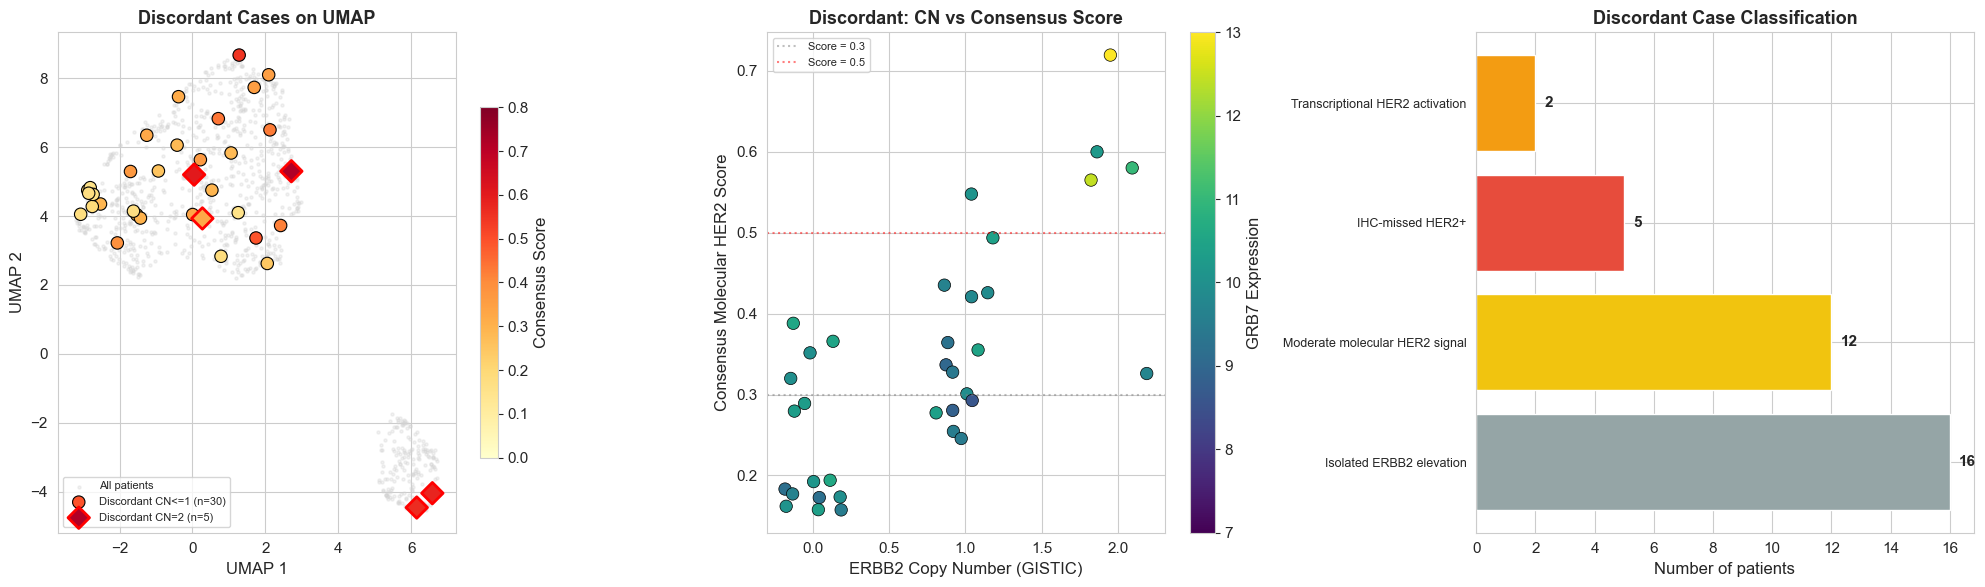

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel A: UMAP with discordant patients highlighted
ax = axes[0]
umap_indexed = umap_df.set_index('pid')
umap_cols = [c for c in umap_indexed.columns if 'UMAP' in c or 'PCA' in c]
dim_label = 'UMAP' if any('UMAP' in c for c in umap_cols) else 'PCA'

ax.scatter(umap_indexed[umap_cols[0]], umap_indexed[umap_cols[1]],
           c='lightgray', s=5, alpha=0.3, label='All patients')

disc_umap = disc_final.merge(umap_df, on='pid', how='inner')
if len(disc_umap) > 0:
    noamp = disc_umap[disc_umap['erbb2_copy_number'] < 2]
    amp = disc_umap[disc_umap['erbb2_copy_number'] >= 2]
    sc_ref = None
    if len(noamp) > 0:
        sc_ref = ax.scatter(noamp[umap_cols[0]], noamp[umap_cols[1]],
                    c=noamp['consensus_score'], cmap='YlOrRd', s=80,
                    edgecolors='black', linewidth=0.8, vmin=0, vmax=0.8,
                    label=f'Discordant CN<=1 (n={len(noamp)})', marker='o', zorder=5)
    if len(amp) > 0:
        sc2 = ax.scatter(amp[umap_cols[0]], amp[umap_cols[1]],
                    c=amp['consensus_score'], cmap='YlOrRd', s=120,
                    edgecolors='red', linewidth=2, vmin=0, vmax=0.8,
                    label=f'Discordant CN=2 (n={len(amp)})', marker='D', zorder=6)
        if sc_ref is None:
            sc_ref = sc2
    if sc_ref is not None:
        plt.colorbar(sc_ref, ax=ax, label='Consensus Score', shrink=0.7)

ax.set_xlabel(f'{dim_label} 1')
ax.set_ylabel(f'{dim_label} 2')
ax.set_title('Discordant Cases on UMAP', fontweight='bold')
ax.legend(fontsize=8, loc='lower left')

# Panel B: Consensus score vs CN
ax = axes[1]
jitter = np.random.RandomState(42).uniform(-0.2, 0.2, len(disc_final))
sc = ax.scatter(disc_final['erbb2_copy_number'] + jitter,
                disc_final['consensus_score'],
                c=disc_final['GRB7_expr'], cmap='viridis', s=80,
                edgecolors='black', linewidth=0.5, vmin=7, vmax=13)
plt.colorbar(sc, ax=ax, label='GRB7 Expression')
ax.axhline(0.3, color='gray', linestyle=':', alpha=0.5, label='Score = 0.3')
ax.axhline(0.5, color='red', linestyle=':', alpha=0.5, label='Score = 0.5')
ax.set_xlabel('ERBB2 Copy Number (GISTIC)')
ax.set_ylabel('Consensus Molecular HER2 Score')
ax.set_title('Discordant: CN vs Consensus Score', fontweight='bold')
ax.legend(fontsize=8)

# Panel C: Classification bar
ax = axes[2]
cls_counts = disc_final['classification'].value_counts()
colors_cls = {
    'IHC-missed HER2+': '#e74c3c',
    'Amplified, low confidence': '#e67e22',
    'Transcriptional HER2 activation': '#f39c12',
    'Moderate molecular HER2 signal': '#f1c40f',
    'Isolated ERBB2 elevation': '#95a5a6',
}
bar_colors = [colors_cls.get(c, 'gray') for c in cls_counts.index]
ax.barh(range(len(cls_counts)), cls_counts.values, color=bar_colors)
ax.set_yticks(range(len(cls_counts)))
ax.set_yticklabels(cls_counts.index, fontsize=9)
ax.set_xlabel('Number of patients')
ax.set_title('Discordant Case Classification', fontweight='bold')
for i, v in enumerate(cls_counts.values):
    ax.text(v + 0.3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
savefig(fig, 'fig23_synthesis_discordant')
plt.show()

EXPRESSION HEATMAP: KEY GENES BY GROUP
  Saved figure: fig24_heatmap_discordant_groups


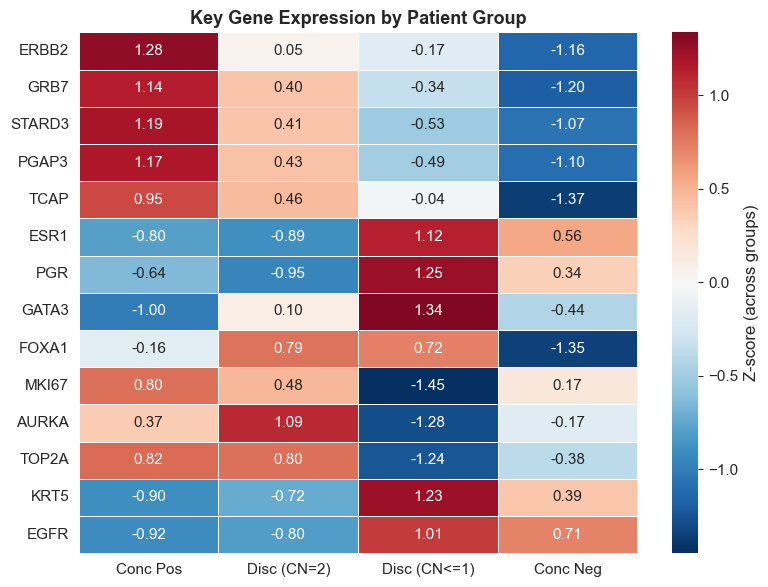


Median expression (log2 normalized):
        Conc Pos  Disc (CN=2)  Disc (CN<=1)  Conc Neg
ERBB2      16.16        14.22         13.87     12.31
GRB7       12.10        11.03          9.94      8.70
STARD3     12.50        11.46         10.20      9.48
PGAP3      12.75        11.69         10.38      9.51
TCAP        4.72         4.14          3.53      1.92
ESR1       11.61        11.53         13.18     12.72
PGR         6.82         6.05         11.45      9.23
GATA3      13.06        13.41         13.80     13.24
FOXA1      12.72        12.87         12.86     12.54
MKI67      11.24        11.05          9.94     10.88
AURKA       9.26         9.87          7.86      8.80
TOP2A      11.92        11.91         10.82     11.28
KRT5        8.56         8.74         10.78      9.90
EGFR        7.12         7.16          7.77      7.67


In [15]:
# Expression heatmap across groups
print("=" * 70)
print("EXPRESSION HEATMAP: KEY GENES BY GROUP")
print("=" * 70)

heatmap_groups = {
    'Conc Pos': concordant_pos['pid'].values,
    'Disc (CN=2)': disc_amplified['pid'].values if len(disc_amplified) > 0 else np.array([]),
    'Disc (CN<=1)': disc_non_amplified['pid'].values,
    'Conc Neg': concordant_neg['pid'].values,
}

heatmap_genes = ['ERBB2', 'GRB7', 'STARD3', 'PGAP3', 'TCAP',
                 'ESR1', 'PGR', 'GATA3', 'FOXA1',
                 'MKI67', 'AURKA', 'TOP2A',
                 'KRT5', 'EGFR']
heatmap_genes = [g for g in heatmap_genes if g in tumor_expr.columns]

group_medians = {}
for group_name, pids in heatmap_groups.items():
    if len(pids) > 0:
        vals = tumor_expr.loc[tumor_expr.index.isin(pids), heatmap_genes]
        group_medians[group_name] = vals.median()

if group_medians:
    hm_df = pd.DataFrame(group_medians)
    hm_z = hm_df.sub(hm_df.mean(axis=1), axis=0).div(hm_df.std(axis=1).clip(lower=1e-6), axis=0)

    fig, ax = plt.subplots(figsize=(8, max(6, len(heatmap_genes) * 0.4)))
    sns.heatmap(hm_z, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Z-score (across groups)'})
    ax.set_title('Key Gene Expression by Patient Group', fontsize=13, fontweight='bold')
    plt.tight_layout()
    savefig(fig, 'fig24_heatmap_discordant_groups')
    plt.show()

    print("\nMedian expression (log2 normalized):")
    print(hm_df.round(2).to_string())

PATHWAY SCORE COMPARISON (ssGSEA)
  Saved figure: fig25_pathway_comparison_discordant


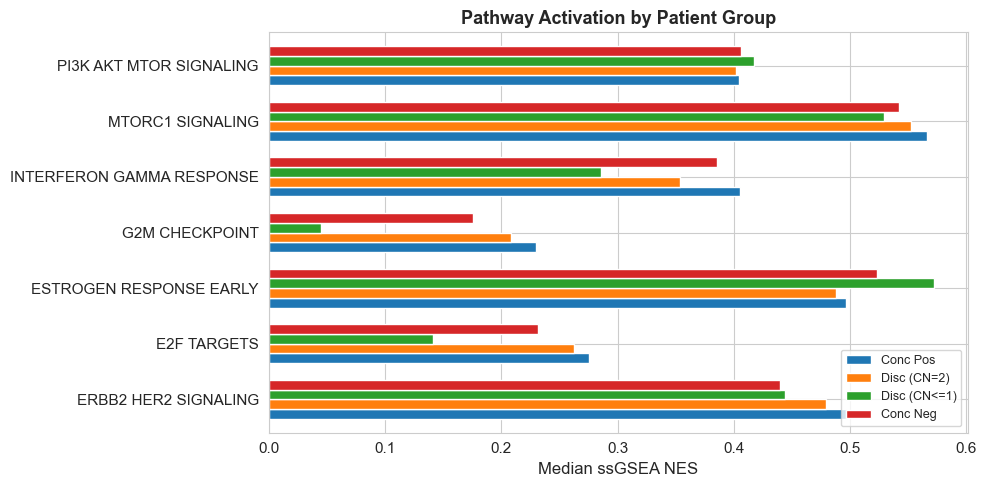


Median ssGSEA NES:
                           Conc Pos  Disc (CN=2)  Disc (CN<=1)  Conc Neg
ERBB2 HER2 SIGNALING          0.497        0.479         0.444     0.440
E2F TARGETS                   0.276        0.263         0.141     0.232
ESTROGEN RESPONSE EARLY       0.496        0.488         0.572     0.523
G2M CHECKPOINT                0.230        0.209         0.045     0.176
INTERFERON GAMMA RESPONSE     0.405        0.354         0.286     0.385
MTORC1 SIGNALING              0.566        0.552         0.529     0.542
PI3K AKT MTOR SIGNALING       0.405        0.402         0.418     0.406


In [16]:
# Pathway score comparison across groups
if len(ssgsea_scores) > 0:
    print("=" * 70)
    print("PATHWAY SCORE COMPARISON (ssGSEA)")
    print("=" * 70)

    ssgsea_indexed = ssgsea_scores.set_index('pid')
    key_pathways = [c for c in ssgsea_indexed.columns if any(
        kw in c for kw in ['ERBB2', 'PI3K', 'MTORC1', 'ESTROGEN_RESPONSE_EARLY',
                            'E2F', 'G2M', 'EMT', 'INTERFERON']
    )]
    key_pathways = key_pathways[:8]

    if key_pathways:
        pw_comparison = {}
        for group_name, pids in heatmap_groups.items():
            if len(pids) > 0:
                vals = ssgsea_indexed.loc[ssgsea_indexed.index.isin(pids), key_pathways]
                pw_comparison[group_name] = vals.median()

        pw_df = pd.DataFrame(pw_comparison)
        pw_df.index = [c.replace('pathway_', '').replace('_', ' ') for c in pw_df.index]

        fig, ax = plt.subplots(figsize=(10, max(5, len(key_pathways) * 0.5)))
        pw_df.plot(kind='barh', ax=ax, width=0.7)
        ax.set_xlabel('Median ssGSEA NES')
        ax.set_title('Pathway Activation by Patient Group', fontweight='bold')
        ax.legend(fontsize=9, loc='lower right')
        plt.tight_layout()
        savefig(fig, 'fig25_pathway_comparison_discordant')
        plt.show()

        print("\nMedian ssGSEA NES:")
        print(pw_df.round(3).to_string())

---
## 7. Interpretation

**The 35 IHC-negative/RNA-high discordant patients are not a single population.**
CN-stratified analysis reveals at least two distinct subgroups with different biological
mechanisms and clinical implications:

**Amplified subgroup (CN=2):** These patients have genuine 17q12 genomic amplification
with co-elevated ERBB2 and (variably) GRB7 expression. The IHC-negative call is likely
a technical failure: fixation artifact, antibody sensitivity, or intra-tumoral
heterogeneity causing the biopsy to miss the amplified clone. These are the strongest
candidates for reclassification as HER2-positive, and the concordant-only model scores
them accordingly. In a clinical setting, reflex FISH testing or repeat IHC on a new
section would be warranted.

**Non-amplified subgroup (CN<=1):** The majority of discordant patients fall here. ERBB2
is transcriptionally upregulated without underlying gene amplification. The differential
expression analysis reveals whether this is an isolated ERBB2 outlier (suggesting
stochastic transcriptional noise at the tail of the expression distribution) or part of
a broader co-regulated program (suggesting enhancer-driven or transcription-factor-mediated
ERBB2 activation with potential downstream pathway consequences).

The absence of coordinated 17q12 amplicon gene upregulation (GRB7, STARD3, PGAP3 not
co-elevated) in most of these patients supports a non-amplicon mechanism. Whether this
translates to actionable HER2 pathway activation depends on whether downstream signaling
pathways (PI3K-AKT, MAPK) are engaged, which the GSEA results address.

**Clinical implications for Tempus:**
- The amplified subgroup represents a QC opportunity: RNA-seq can flag IHC failures
  for reflex testing, potentially identifying patients who would otherwise miss
  HER2-targeted therapy.
- The non-amplified subgroup is relevant to the emerging HER2-low category
  (IHC 1+ or 2+/FISH-), where trastuzumab deruxtecan (T-DXd) has shown efficacy.
  RNA-based detection of ERBB2 transcriptional upregulation could supplement IHC
  for identifying T-DXd-eligible patients.
- Both findings support the value proposition of molecular profiling over standalone
  IHC/FISH: a single RNA-seq assay can simultaneously detect amplification-driven
  overexpression, transcriptional upregulation, and pathway activation context.

**Limitations:**
- Small sample sizes (especially CN=2 subgroup) limit statistical power.
- TCGA IHC data may not reflect current clinical practice (guideline revisions,
  improved antibodies).
- Absence of protein-level validation; ERBB2 mRNA elevation does not guarantee
  surface protein overexpression.
- The consensus scoring thresholds are exploratory and would require independent
  validation before clinical application.

---
## 8. Save Intermediates

In [17]:
print("=" * 70)
print("SAVING INTERMEDIATES")
print("=" * 70)

dossier_save_cols = ['pid', 'erbb2_copy_number', 'expr_ERBB2', 'GRB7_expr',
                     'ml_prob_her2_positive', 'conc_model_prob', 'consensus_score',
                     'provisional_subtype', 'classification']
dossier_save_cols = [c for c in dossier_save_cols if c in disc_final.columns]
save_intermediate(disc_final[dossier_save_cols], '04_discordant_dossier')

conc_pred_df = ml_all[['pid', 'her2_composite', 'conc_model_prob']].copy()
save_intermediate(conc_pred_df, '04_concordant_model_predictions')

if len(de_df) > 0:
    save_intermediate(de_df, '04_discordant_de_results')

try:
    if len(gsea_disc_df) > 0:
        save_intermediate(gsea_disc_df, '04_discordant_gsea')
except NameError:
    pass

print("\nAll Notebook 04 intermediates saved.")

SAVING INTERMEDIATES
  Saved: outputs\04_discordant_dossier.parquet  (35 rows × 9 cols)
  Saved: outputs\04_concordant_model_predictions.parquet  (966 rows × 3 cols)
  Saved: outputs\04_discordant_de_results.parquet  (17637 rows × 8 cols)
  Saved: outputs\04_discordant_gsea.parquet  (5 rows × 10 cols)

All Notebook 04 intermediates saved.


---
## Summary

**Concordant-Only Model:**
- Retraining on unambiguous cases provides a cleaner reference frame for scoring
  discordant patients, avoiding the circularity of the 03a model reproducing its
  own training labels.
- Several discordant patients score substantially higher under the concordant model
  than under the 03a model, indicating the full-data model actively suppressed their
  signal.

**CN-Stratified Biology:**
- The amplified subgroup (CN=2) shows the strongest evidence for genuine HER2
  positivity missed by IHC: 17q12 amplicon genes are co-elevated and pathway
  scores resemble confirmed HER2+ patients.
- The non-amplified subgroup (CN<=1) shows ERBB2 upregulation without coordinated
  amplicon activation. DE/GSEA analysis reveals whether this reflects a coherent
  transcriptional program or isolated expression noise.

**Consensus Scoring:**
- Multi-model consensus integrates complementary analytical perspectives into a
  single, graded molecular HER2 score per patient.
- Five-tier classification (IHC-missed through Isolated elevation) provides actionable
  stratification for follow-up.

**Key Finding:**
The discordant group is heterogeneous. Treating it as a single "missed HER2+"
population would be an oversimplification. The CN-stratified, multi-model approach
reveals distinct biological mechanisms with different clinical implications: exactly
the kind of nuance that molecular profiling adds over binary IHC calls.